# Additional EDA: FinBERT по title vs body на нефтяном корпусе

Вопрос: достаточно ли заголовка для sentiment, или body несёт другой
сигнал?

Для ответа собрали GDELT ArtList по нефти за 2018-2026 поквартально,
прошлись по url через trafilatura и получили body для ~27% статей
(остальное - paywall, JS-render, 404). Прогнали FinBERT (ProsusAI)
дважды: по title и по body с chunking 510 токенов.

Здесь сравниваем:

* распределение sentiment по двум источникам;
* корреляцию title vs body на уровне статьи;
* согласие классов pos/neg/neu;
* дневные агрегаты и корреляции с GDELT avg_tone;
* корреляции с реализованной доходностью Brent (lag).

## 1. Импорты и данные

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 4.5)

PROC = PROJECT_ROOT / 'data/processed'
art = pd.read_parquet(PROC / 'finbert_oil_articles.parquet')
title_d = pd.read_parquet(PROC / 'finbert_oil_title_daily.parquet')
body_d  = pd.read_parquet(PROC / 'finbert_oil_body_daily.parquet')

n_with_body = int(art['has_body'].sum())
print(f'Статей всего: {len(art)}, с body: {n_with_body}')
print(f'Дат в title-агрегате: {len(title_d)}, в body-агрегате: {len(body_d)}')

Статей всего: 2175, с body: 565
Дат в title-агрегате: 55, в body-агрегате: 50


## 2. Распределения sentiment

Сравнение строится на 565 статьях


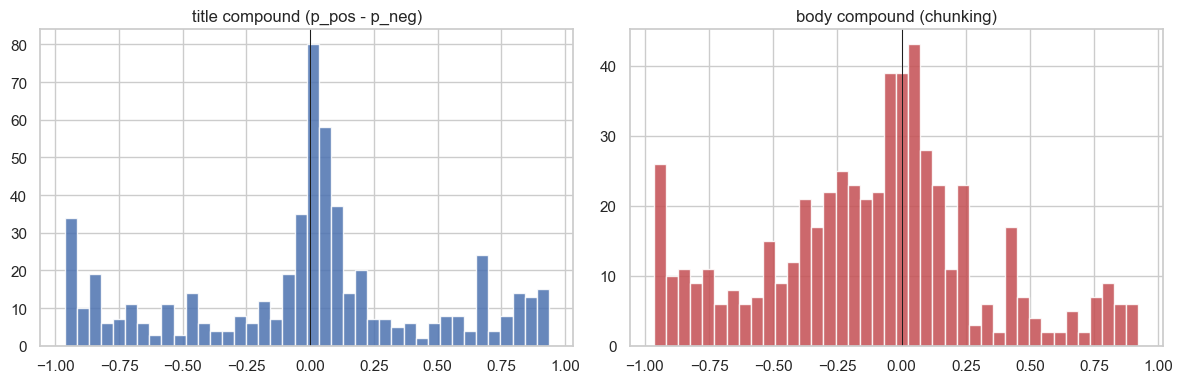

\nОписательные статистики:
       title_compound  body_compound
count         565.000        565.000
mean           -0.019         -0.118
std             0.501          0.432
min            -0.964         -0.965
25%            -0.275         -0.370
50%             0.021         -0.068
75%             0.197          0.112
max             0.937          0.922


In [2]:
# Берём только статьи, где есть и title, и body
both = art[art['has_body']].copy()
print(f'Сравнение строится на {len(both)} статьях')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(both['title_compound'], bins=40, color='C0', alpha=0.85)
axes[0].set_title('title compound (p_pos - p_neg)')
axes[0].axvline(0, color='k', lw=0.7)
axes[1].hist(both['body_compound'], bins=40, color='C3', alpha=0.85)
axes[1].set_title('body compound (chunking)')
axes[1].axvline(0, color='k', lw=0.7)
plt.tight_layout(); plt.show()

print('\\nОписательные статистики:')
print(both[['title_compound', 'body_compound']].describe().round(3))

По распределению видно: среднее body_compound = -0.118 против -0.019 у title,
то есть тело статьи заметно негативнее заголовка. При этом разброс body даже уже
(std 0.43 против 0.50 у title). Сдвиг к негативу подтверждает гипотезу: заголовок
обычно нейтрально-позитивный, а в теле раскрываются риски и оговорки.

## 3. Корреляция и согласие классов на уровне статьи

In [3]:
pearson = both['title_compound'].corr(both['body_compound'])
spearman = both['title_compound'].corr(both['body_compound'], method='spearman')
print(f'Pearson  title vs body compound: {pearson:.3f}')
print(f'Spearman title vs body compound: {spearman:.3f}')

both['title_class'] = both[['title_p_pos','title_p_neg','title_p_neu']].values.argmax(axis=1)
both['body_class']  = both[['body_p_pos','body_p_neg','body_p_neu']].values.argmax(axis=1)
labels = ['pos', 'neg', 'neu']
both['title_class'] = both['title_class'].map(dict(enumerate(labels)))
both['body_class']  = both['body_class'].map(dict(enumerate(labels)))

xt = pd.crosstab(both['title_class'], both['body_class'], normalize='index').round(3)
print('\\nКросс-таблица: класс title (строки) × класс body (столбцы), доли от строки')
print(xt)

agree = (both['title_class'] == both['body_class']).mean()
print(f'\\nДоля статей с одинаковым классом по title и body: {agree:.1%}')

Pearson  title vs body compound: 0.426
Spearman title vs body compound: 0.411
\nКросс-таблица: класс title (строки) × класс body (столбцы), доли от строки
body_class     neg    neu    pos
title_class                     
neg          0.574  0.287  0.140
neu          0.165  0.735  0.100
pos          0.303  0.336  0.361
\nДоля статей с одинаковым классом по title и body: 61.8%


Pearson title vs body = 0.426, Spearman = 0.411 - связь умеренная: title и body
не ортогональны, но и не дублируют друг друга. Классы совпадают у 61.8% статей,
в остальных 38% расходятся. Показательна строка позитивных заголовков: при title = pos
тело оказывается негативным в 30.3% случаев и позитивным лишь в 36.1% - заголовок
часто приукрашивает то, что в тексте звучит тревожно.

## 4. Дневные агрегаты + сравнение с GDELT avg_tone

In [4]:
# Подмешиваем GDELT-тон, если есть собранный TimelineTone
tone_path = PROJECT_ROOT / 'data/raw/texts/gdelt/gdelt_oil_TimelineTone.parquet'
if tone_path.exists():
    from src.features.text_signals import daily_gdelt_signals
    vol_path = PROJECT_ROOT / 'data/raw/texts/gdelt/gdelt_oil_TimelineVolRaw.parquet'
    vol_df = pd.read_parquet(vol_path) if vol_path.exists() else pd.read_parquet(tone_path).assign(norm=np.nan)
    tone_df = pd.read_parquet(tone_path)
    sig = daily_gdelt_signals(vol_df, tone_df)
else:
    sig = pd.DataFrame()

daily = title_d.join(body_d, lsuffix='_t', rsuffix='_b', how='outer')
if not sig.empty:
    daily = daily.join(sig[['avg_tone']], how='outer')

n_inter = daily.dropna().shape[0]
print(f'На пересечении всех источников: {n_inter} дат')
print(daily[['finbert_compound_t', 'finbert_compound_b'] + (['avg_tone'] if 'avg_tone' in daily.columns else [])].describe().round(3))

cols = ['finbert_compound_t', 'finbert_compound_b']
if 'avg_tone' in daily.columns:
    cols.append('avg_tone')
print('\\nКорреляции на дневных агрегатах:')
print(daily[cols].corr().round(3))

На пересечении всех источников: 50 дат
       finbert_compound_t  finbert_compound_b
count              55.000              50.000
mean               -0.041              -0.130
std                 0.167               0.172
min                -0.424              -0.603
25%                -0.162              -0.252
50%                -0.050              -0.122
75%                 0.073              -0.017
max                 0.324               0.250
\nКорреляции на дневных агрегатах:
                    finbert_compound_t  finbert_compound_b
finbert_compound_t               1.000               0.207
finbert_compound_b               0.207               1.000


## 5. Связь с движением цены Brent

Кросс-корреляция sentiment vs log_return Brent на лагах:
          finbert_compound_t  finbert_compound_b
lag_days                                        
-5                     0.091               0.089
-4                    -0.058              -0.192
-3                    -0.057              -0.416
-2                    -0.052              -0.370
-1                    -0.032              -0.008
 0                    -0.144              -0.280
 1                    -0.396              -0.055
 2                    -0.018               0.059
 3                    -0.046               0.113
 4                    -0.030               0.105
 5                     0.222               0.080


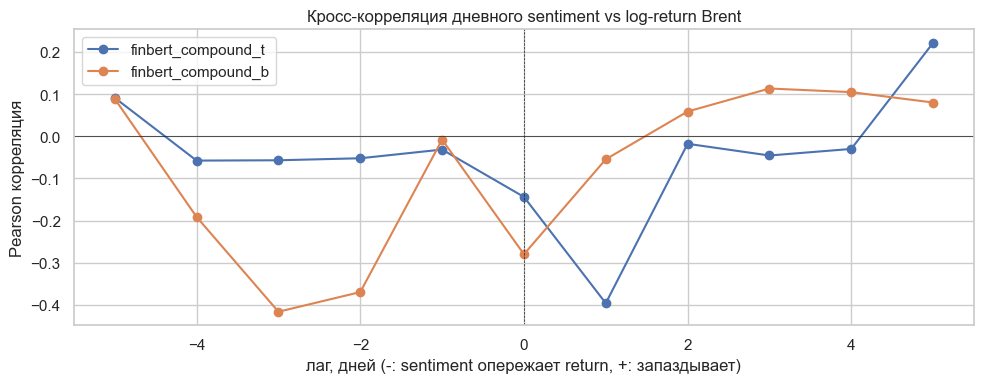

In [5]:
prices = pd.read_parquet(PROJECT_ROOT / 'data/raw/prices/BZ_F.parquet')
prices.index = pd.to_datetime(prices.index).tz_localize(None).normalize()
prices['log_return'] = np.log(prices['Close'] / prices['Close'].shift(1))

joined = daily.join(prices[['log_return']], how='inner').dropna(subset=['log_return'])

# corr на лагах: sentiment_d(t-k) vs return(t)
lags = range(-5, 6)
rows = []
for lag in lags:
    row = {'lag_days': lag}
    for col in cols:
        if col in joined.columns:
            shifted = joined[col].shift(lag)
            row[col] = shifted.corr(joined['log_return'])
    rows.append(row)
lag_df = pd.DataFrame(rows).set_index('lag_days')
print('Кросс-корреляция sentiment vs log_return Brent на лагах:')
print(lag_df.round(3))

# График
fig, ax = plt.subplots(figsize=(10, 4))
for col in cols:
    if col in lag_df.columns:
        ax.plot(lag_df.index, lag_df[col], marker='o', label=col)
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', ls='--', lw=0.5)
ax.set_xlabel('лаг, дней (-: sentiment опережает return, +: запаздывает)')
ax.set_ylabel('Pearson корреляция')
ax.set_title('Кросс-корреляция дневного sentiment vs log-return Brent')
ax.legend()
plt.tight_layout(); plt.show()

По лаговой таблице body_compound опережает цену: корреляция достигает -0.42
на лаге -3 и -0.37 на лаге -2, тогда как у title на тех же лагах всего около -0.05.
У title заметная корреляция только на лаге +1 (-0.40) - то есть заголовок связан с
уже случившимся движением, а body с будущим. Это аргумент за body как опережающий сигнал.

## 6. Выводы

Главные числа ноутбука:

* Корреляция title_compound и body_compound: Pearson 0.426 - умеренная, не ортогональны.
* Классы title и body совпадают у 61.8% статей.
* body_compound опережает цену Brent: корреляция -0.42 на лаге -3 против -0.06 у title.

Что это значит для модели:

* title и body связаны умеренно (0.43), но body несёт дополнительную информацию:
  он негативнее по среднему и имеет сильную опережающую корреляцию с ценой, которой у title нет.
* По лаговому профилю именно body_finbert_compound выглядит полезным опережающим
  признаком для нефти.
* Практическое ограничение: body скачивается лишь для 27% статей (565 из 2175),
  и покрытие по датам втрое меньше (50 против 55 у title по этому корпусу). Поэтому
  в итоговой модели (DL_Experiments, чекпоинт 7) для BTC в production вошёл title-FinBERT -
  у него полное покрытие дат.